In [ ]:
%load_ext autoreload
%autoreload 2


from trees.linear import LinearIV
from trees.experiment import Experiment

from trees.topk import *

exp = Experiment("Top-K Algorithm", 
                    k=[3],
                    exp_name="exhaustive",
                    user_iterations=10,
                    mode=["OTC", "UTC", "RCT", "CU-visit"], 
                    min_s=[0.4], 
                    topk_methods=exhaustive_comparison
                )


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000602 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 60
[LightGBM] [Info] Number of data points in the train set: 100000, number of used features: 3
[LightGBM] [Info] Start training from score 9.952170
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 35220, number of negative: 64780
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000562 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 62
[LightGBM] [Info] Number of data points in

2025-08-30 13:10:48.904 | INFO     | trees.experiment:__init__:87 - 	 [Pretrained] LinearIV - Offline time: 0:00:17.330432
100%|██████████| 10/10 [1:13:02<00:00, 438.22s/it]
2025-08-30 14:23:51.153 | INFO     | trees.experiment:__init__:75 - Generating data: {'n': 100000, 'p': 10, 'sigma': 3.0, 'seed': 0, 'mode': 'UTC'}
2025-08-30 14:23:51.303 | INFO     | trees.causal_forest:fit:191 - Using pretrained model /Users/antonismand/Documents/Work/phD/HTE_in_OLAP/trees/../models/CFT_UTC.pkl
2025-08-30 14:23:51.345 | INFO     | trees.experiment:__init__:87 - 	 [Pretrained] CF - Offline time: 0:00:00.044238
100%|██████████| 10/10 [2:05:58<00:00, 755.84s/it] 
2025-08-30 16:29:49.717 | INFO     | trees.experiment:__init__:75 - Generating data: {'n': 100000, 'p': 10, 'sigma': 3.0, 'seed': 0, 'mode': 'RCT'}
2025-08-30 16:29:49.883 | INFO     | trees.causal_forest:fit:191 - Using pretrained model /Users/antonismand/Documents/Work/phD/HTE_in_OLAP/trees/../models/CFT_RCT.pkl
2025-08-30 16:29:50.081 |

In [2]:
from trees.experiment import LoadExperiment
exp = LoadExperiment("exhaustive")
df = exp.scores
df

,id,condition,combined,Features,t_est,Depth,estimator,parents,final_condition,Top-K Algorithm,...,t_r,Overlap,Number of rows,t_error,t_r_error,Max Overlap,iteration,Q,Q_selectivity,dataset
0,2307.0,days_visited_free_pre > 14.50000 AND days_visi...,"{'days_visited_free_pre': (27.5, 28.0), 'days_...",3.0,9.353,10.0,[Pretrained] LinearIV,"[1740, 1741, 2133, 2134, 2246, 2288, 2289, 230...",days_visited_exp_pre <= 15.42 AND days_visited...,ExhaustiveDiRe,...,9.600,0.00,22.0,0.247,0.000,0.00,0,days_visited_exp_pre <= 15.42,0.551380,OTC
1,2266.0,days_visited_free_pre > 14.50000 AND days_visi...,"{'days_visited_free_pre': (27.5, 28.0), 'days_...",3.0,8.389,10.0,[Pretrained] LinearIV,"[1740, 1741, 2133, 2134, 2246, 2247, 2248, 226...",days_visited_exp_pre <= 15.42 AND days_visited...,ExhaustiveDiRe,...,8.600,0.00,40.0,0.211,0.000,0.00,0,days_visited_exp_pre <= 15.42,0.551380,OTC
2,3322.0,days_visited_free_pre > 14.50000 AND days_visi...,"{'days_visited_free_pre': (27.5, 28.0), 'days_...",3.0,5.200,10.0,[Pretrained] LinearIV,"[1740, 2524, 2944, 3140, 3236, 3300, 3301, 331...",days_visited_exp_pre <= 15.42 AND days_visited...,ExhaustiveDiRe,...,5.268,0.00,47.0,0.064,0.004,0.00,0,days_visited_exp_pre <= 15.42,0.551380,OTC
3,2307.0,days_visited_free_pre > 14.50000 AND days_visi...,"{'days_visited_free_pre': (27.5, 28.0), 'days_...",3.0,9.353,10.0,[Pretrained] LinearIV,"[1740, 1741, 2133, 2134, 2246, 2288, 2289, 230...",days_visited_exp_pre <= 15.42 AND days_visited...,DiRe,...,9.600,0.25,22.0,0.247,0.000,0.25,0,days_visited_exp_pre <= 15.42,0.551380,OTC
4,2306.0,days_visited_free_pre > 14.50000 AND days_visi...,"{'days_visited_free_pre': (27.5, 28.0), 'days_...",3.0,9.266,9.0,[Pretrained] LinearIV,"[1740, 1741, 2133, 2134, 2246, 2288, 2289, 2305]",days_visited_exp_pre <= 15.42 AND days_visited...,DiRe,...,9.500,0.50,44.0,0.243,0.009,0.25,0,days_visited_exp_pre <= 15.42,0.551380,OTC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
697,2311.0,f3 <= 2.16680 AND f8 > 3.88155 AND f8 <= 3.939...,"{'f3': (-8.398, 1.5239), 'f8': (3.88155, 3.913...",6.0,0.070,12.0,[Pretrained] CF,"[1, 1927, 1928, 1929, 2177, 2305, 2306, 2307, ...",f6 > -13.348 AND f3 <= 2.16680 AND f8 > 3.8815...,ExhaustiveReCoD,...,0.070,NaN,NaN,NaN,NaN,NaN,9,f6 > -13.348,0.949226,CU-visit
698,4675.0,f3 > 2.16680 AND f8 <= 3.88155 AND f3 <= 4.293...,"{'f3': (2.1668, 3.14727), 'f8': (3.635, 3.7940...",5.0,0.064,11.0,[Pretrained] CF,"[3902, 3903, 3904, 4408, 4662, 4663, 4664, 466...",f6 > -13.348 AND f3 > 2.16680 AND f8 <= 3.8815...,ExhaustiveReCoD,...,0.064,NaN,NaN,NaN,NaN,NaN,9,f6 > -13.348,0.949226,CU-visit
699,5489.0,f3 > 2.16680 AND f8 <= 3.88155 AND f3 > 4.2937...,"{'f3': (4.29377, 4.68), 'f8': (3.635, 3.72389)...",6.0,0.060,12.0,[Pretrained] CF,"[3902, 3903, 4911, 5413, 5414, 5415, 5471, 547...",f6 > -13.348 AND f3 > 2.16680 AND f8 <= 3.8815...,ReCoD,...,0.060,NaN,NaN,NaN,NaN,NaN,9,f6 > -13.348,0.949226,CU-visit
700,2888.0,f3 <= 2.16680 AND f8 > 3.88155 AND f8 <= 3.939...,"{'f3': (-8.398, 2.1668), 'f8': (3.90865, 3.939...",6.0,0.030,12.0,[Pretrained] CF,"[1, 1927, 1928, 2432, 2688, 2812, 2876, 2877, ...",f6 > -13.348 AND f3 <= 2.16680 AND f8 > 3.8815...,ReCoD,...,0.030,NaN,NaN,NaN,NaN,NaN,9,f6 > -13.348,0.949226,CU-visit


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


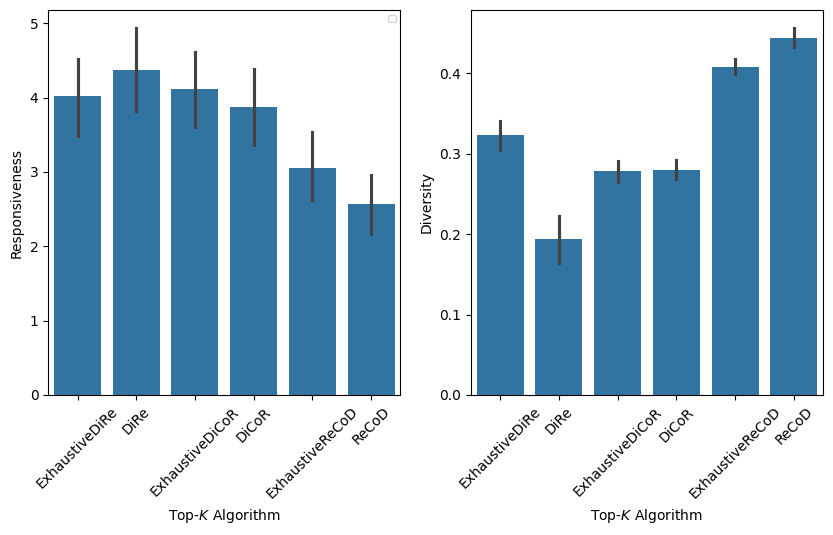

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


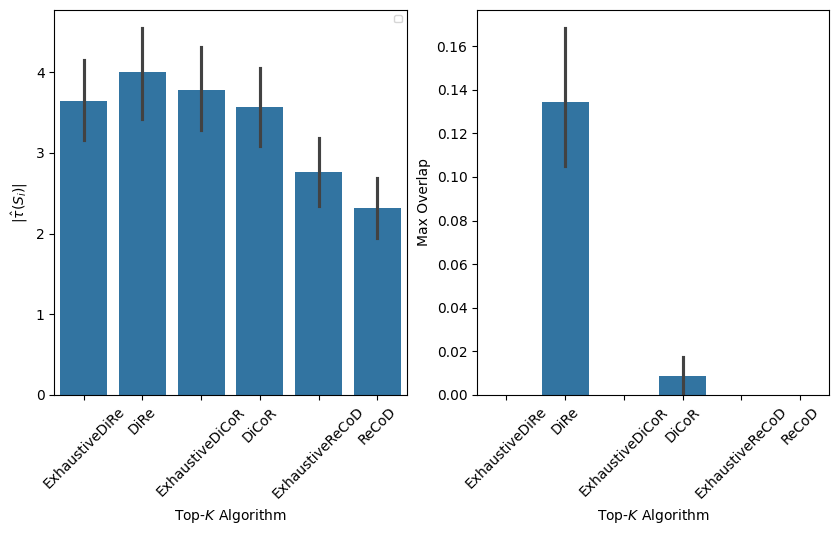

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


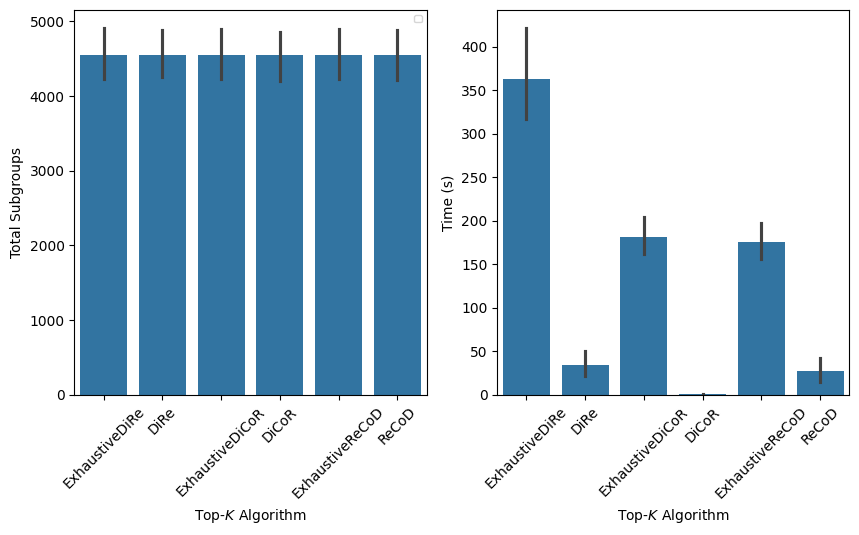

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


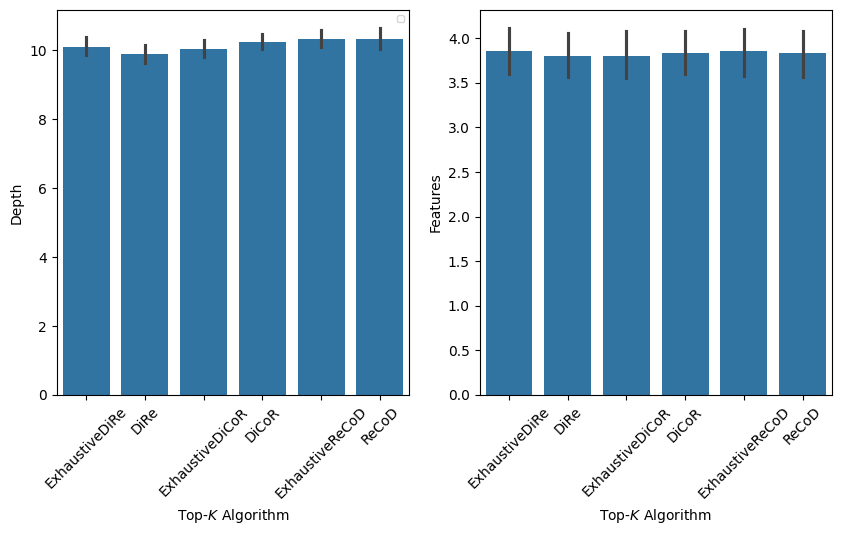

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


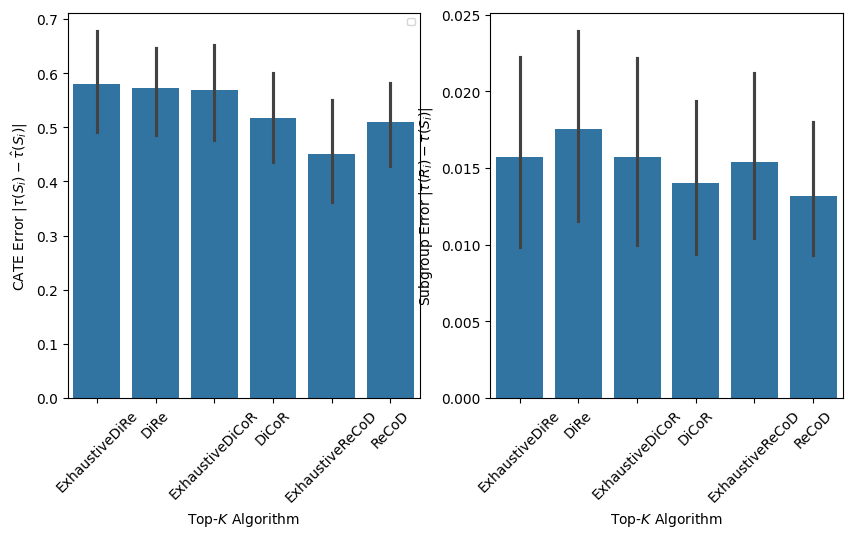

In [3]:
exp.plots(hue=None, rotation=45)

In [ ]:
def compare_to_exhaustive(alg, exhaustive):
    s = exp.scores
    # Mean
    CATE_mean = round(s[s['Top-K Algorithm']==alg]['t'].mean()/s[s['Top-K Algorithm']==exhaustive]['t'].mean(), 2)
    diversity_mean = round(s[s['Top-K Algorithm']==alg]['Diversity'].mean()/s[s['Top-K Algorithm']==exhaustive]['Diversity'].mean(),2)
    # Percentiles
    CATE_10 = round(s[s['Top-K Algorithm']==alg]['t'].quantile(0.10)/s[s['Top-K Algorithm']==exhaustive]['t'].quantile(0.10), 2)
    CATE_90 = round(s[s['Top-K Algorithm']==alg]['t'].quantile(0.90)/s[s['Top-K Algorithm']==exhaustive]['t'].quantile(0.90), 2)
    diversity_10 = round(s[s['Top-K Algorithm']==alg]['Diversity'].quantile(0.10)/s[s['Top-K Algorithm']==exhaustive]['Diversity'].quantile(0.10),2)
    diversity_90 = round(s[s['Top-K Algorithm']==alg]['Diversity'].quantile(0.90)/s[s['Top-K Algorithm']==exhaustive]['Diversity'].quantile(0.90),2)
    print(f"{alg} % Exhaustive {CATE_mean=}, {CATE_10=}, {CATE_90=}, {diversity_mean=}, {diversity_10=}, {diversity_90=}")
    return (CATE_mean, CATE_10, CATE_90), (diversity_mean, diversity_10, diversity_90)

,id,condition,combined,Features,t_est,Depth,estimator,parents,final_condition,Top-K Algorithm,...,t_r,Overlap,Number of rows,t_error,t_r_error,Max Overlap,iteration,Q,Q_selectivity,dataset
0,2307.0,days_visited_free_pre > 14.50000 AND days_visi...,"{'days_visited_free_pre': (27.5, 28.0), 'days_...",3.0,9.353,10.0,[Pretrained] LinearIV,"[1740, 1741, 2133, 2134, 2246, 2288, 2289, 230...",days_visited_exp_pre <= 15.42 AND days_visited...,ExhaustiveDiRe,...,9.600,0.00,22.0,0.247,0.000,0.00,0,days_visited_exp_pre <= 15.42,0.551380,OTC
1,2266.0,days_visited_free_pre > 14.50000 AND days_visi...,"{'days_visited_free_pre': (27.5, 28.0), 'days_...",3.0,8.389,10.0,[Pretrained] LinearIV,"[1740, 1741, 2133, 2134, 2246, 2247, 2248, 226...",days_visited_exp_pre <= 15.42 AND days_visited...,ExhaustiveDiRe,...,8.600,0.00,40.0,0.211,0.000,0.00,0,days_visited_exp_pre <= 15.42,0.551380,OTC
2,3322.0,days_visited_free_pre > 14.50000 AND days_visi...,"{'days_visited_free_pre': (27.5, 28.0), 'days_...",3.0,5.200,10.0,[Pretrained] LinearIV,"[1740, 2524, 2944, 3140, 3236, 3300, 3301, 331...",days_visited_exp_pre <= 15.42 AND days_visited...,ExhaustiveDiRe,...,5.268,0.00,47.0,0.064,0.004,0.00,0,days_visited_exp_pre <= 15.42,0.551380,OTC
3,2307.0,days_visited_free_pre > 14.50000 AND days_visi...,"{'days_visited_free_pre': (27.5, 28.0), 'days_...",3.0,9.353,10.0,[Pretrained] LinearIV,"[1740, 1741, 2133, 2134, 2246, 2288, 2289, 230...",days_visited_exp_pre <= 15.42 AND days_visited...,DiRe,...,9.600,0.25,22.0,0.247,0.000,0.25,0,days_visited_exp_pre <= 15.42,0.551380,OTC
4,2306.0,days_visited_free_pre > 14.50000 AND days_visi...,"{'days_visited_free_pre': (27.5, 28.0), 'days_...",3.0,9.266,9.0,[Pretrained] LinearIV,"[1740, 1741, 2133, 2134, 2246, 2288, 2289, 2305]",days_visited_exp_pre <= 15.42 AND days_visited...,DiRe,...,9.500,0.50,44.0,0.243,0.009,0.25,0,days_visited_exp_pre <= 15.42,0.551380,OTC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
697,2311.0,f3 <= 2.16680 AND f8 > 3.88155 AND f8 <= 3.939...,"{'f3': (-8.398, 1.5239), 'f8': (3.88155, 3.913...",6.0,0.070,12.0,[Pretrained] CF,"[1, 1927, 1928, 1929, 2177, 2305, 2306, 2307, ...",f6 > -13.348 AND f3 <= 2.16680 AND f8 > 3.8815...,ExhaustiveReCoD,...,0.070,NaN,NaN,NaN,NaN,NaN,9,f6 > -13.348,0.949226,CU-visit
698,4675.0,f3 > 2.16680 AND f8 <= 3.88155 AND f3 <= 4.293...,"{'f3': (2.1668, 3.14727), 'f8': (3.635, 3.7940...",5.0,0.064,11.0,[Pretrained] CF,"[3902, 3903, 3904, 4408, 4662, 4663, 4664, 466...",f6 > -13.348 AND f3 > 2.16680 AND f8 <= 3.8815...,ExhaustiveReCoD,...,0.064,NaN,NaN,NaN,NaN,NaN,9,f6 > -13.348,0.949226,CU-visit
699,5489.0,f3 > 2.16680 AND f8 <= 3.88155 AND f3 > 4.2937...,"{'f3': (4.29377, 4.68), 'f8': (3.635, 3.72389)...",6.0,0.060,12.0,[Pretrained] CF,"[3902, 3903, 4911, 5413, 5414, 5415, 5471, 547...",f6 > -13.348 AND f3 > 2.16680 AND f8 <= 3.8815...,ReCoD,...,0.060,NaN,NaN,NaN,NaN,NaN,9,f6 > -13.348,0.949226,CU-visit
700,2888.0,f3 <= 2.16680 AND f8 > 3.88155 AND f8 <= 3.939...,"{'f3': (-8.398, 2.1668), 'f8': (3.90865, 3.939...",6.0,0.030,12.0,[Pretrained] CF,"[1, 1927, 1928, 2432, 2688, 2812, 2876, 2877, ...",f6 > -13.348 AND f3 <= 2.16680 AND f8 > 3.8815...,ReCoD,...,0.030,NaN,NaN,NaN,NaN,NaN,9,f6 > -13.348,0.949226,CU-visit


In [3]:
def compare_to_exhaustive(alg):
    exhaustive = "Exhaustive" + alg
    s = exp.scores
    
    # Get describe for each
    desc_alg = s[s['Top-K Algorithm'] == alg][['t', 'Diversity']].describe(percentiles=[0.25, 0.75])
    desc_exh = s[s['Top-K Algorithm'] == exhaustive][['t', 'Diversity']].describe(percentiles=[0.25, 0.75])

    # Compute ratio (alg / exhaustive)
    ratio = desc_alg / desc_exh

    # Round for readability
    ratio = ratio.round(2)

    return ratio


In [5]:
compare_to_exhaustive("DiCoR")

,t,Diversity
count,1.00,1.00
mean,0.94,1.00
std,0.99,0.95
min,1.17,1.01
25%,0.90,1.00
50%,0.92,1.03
75%,1.00,1.00
max,1.00,0.93


In [6]:
compare_to_exhaustive("ReCoD")

,t,Diversity
count,1.00,1.00
mean,0.84,1.09
std,0.97,1.34
min,0.33,0.93
25%,0.68,1.08
50%,1.04,1.09
75%,0.79,1.14
max,1.00,1.06


In [4]:
compare_to_exhaustive("DiRe")

,t,Diversity
count,1.00,1.00
mean,1.08,0.60
std,1.20,1.61
min,1.18,0.09
25%,1.00,0.13
50%,1.01,0.43
75%,1.64,0.90
max,1.00,0.98


OptRes % Exhaustive CATE=0.94, diversity=1.0
OptDiv % Exhaustive CATE=0.93, diversity=0.97
ResDiv % Exhaustive CATE=1.03, diversity=0.84


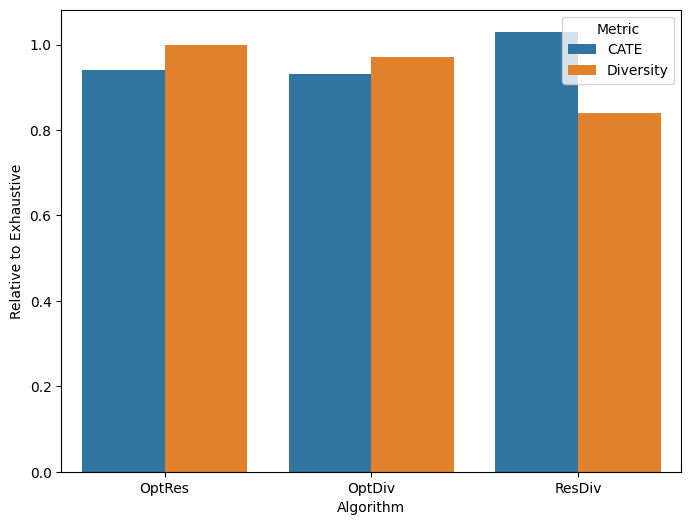

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get the values
CATE, diversity = compare_to_exhaustive("OptRes", "ExhaustiveOptRes")
CATE_OptDiv, diversity_OptDiv = compare_to_exhaustive("OptDiv", "ExhaustiveOptDiv")
CATE_ResDiv, diversity_ResDiv = compare_to_exhaustive("ResDiv", "ExhaustiveResDiv")

# Create a dataframe for plotting
plot_data = pd.DataFrame({
    'Algorithm': ['OptRes', 'OptRes', 'OptDiv', 'OptDiv', 'ResDiv', 'ResDiv'],
    'Relative to Exhaustive': [CATE, diversity, CATE_OptDiv, diversity_OptDiv, CATE_ResDiv, diversity_ResDiv],
    'Metric': ['CATE', 'Diversity', 'CATE', 'Diversity', 'CATE', 'Diversity']
})

# Plot the data
plt.figure(figsize=(8, 6))
sns.barplot(x='Algorithm', y='Relative to Exhaustive', hue='Metric', data=plot_data)
# plt.title('Relative Performance to Exhaustive Algorithms')
plt.show() 